# 02 — Build Author-Paper Table & Career Stage Labels

**Goal:** Flatten award-winning papers into author-paper pairs, pull each author's OpenAlex
career profile, compute career age at the award year, and label Junior (<=5) / Senior (>=6).

**Input:**
- `data/matched/huang_matched_openalex.csv` (the one reused thesis file)
- `conf_data/01_unmatched_papers.csv` (from notebook 01 — papers to exclude, no OpenAlex ID)

**Career age definition:** `career_age_at_award = award_year - first_pub_year`, where
`first_pub_year` is the **absolute first publication year** returned by OpenAlex for that author
(any field/topic, not restricted to CS). This is a simplification for now — noted as a limitation
below, could be revisited as a robustness check restricted to CS-relevant works only.

**Junior/Senior threshold:** Junior = career_age <= 5. Senior = career_age >= 6.


## Setup

In [2]:
import pandas as pd
import numpy as np
import ast
import requests
import time
from pathlib import Path

pd.set_option('display.max_colwidth', 120)

RAW_PATH = "../../data/matched/huang_matched_openalex.csv"
DATA_DIR = Path('../conf_data')
DATA_DIR.mkdir(exist_ok=True)

OPENALEX_API_KEY = "LojPLyiN5Hly8F5xX6YbHu"
MAILTO = "sherotowshaw@gmail.com"  # replace with your real email for OpenAlex polite pool
BASE_URL = "https://api.openalex.org"

df = pd.read_csv(RAW_PATH)
unmatched = pd.read_csv(DATA_DIR / '01_unmatched_papers.csv')
print(df.shape, unmatched.shape)


(925, 10) (22, 10)


## Step 1 — Drop unmatched papers, flatten authorships

In [3]:
matched = df[df['openalex_id'].notna()].copy()
print(f"Matched papers carried forward: {len(matched)} (excluded {len(unmatched)} unmatched)")

rows = []
skipped_no_author_id = 0

for _, row in matched.iterrows():
    if pd.isna(row['authorships']):
        continue
    try:
        auths = ast.literal_eval(row['authorships'])
    except Exception:
        continue
    for a in auths:
        aid = a.get('author', {}).get('id')
        if not aid:
            skipped_no_author_id += 1
            continue
        rows.append({
            'paper_openalex_id': row['openalex_id'],
            'paper_title': row['paper_title'],
            'conference': row['conference'],
            'award_year': row['year'],
            'author_id': aid,
            'author_name': a.get('author', {}).get('display_name'),
            'author_position': a.get('author_position'),
        })

award_authors_long = pd.DataFrame(rows)
print(f"Author-paper pairs: {len(award_authors_long)}")
print(f"Unique authors: {award_authors_long['author_id'].nunique()}")
print(f"Author entries skipped (no OpenAlex author id): {skipped_no_author_id}")

award_authors_long.to_csv(DATA_DIR / '02_award_authors_long.csv', index=False)
award_authors_long.head()


Matched papers carried forward: 903 (excluded 22 unmatched)
Author-paper pairs: 3150
Unique authors: 2710
Author entries skipped (no OpenAlex author id): 52


,paper_openalex_id,paper_title,conference,award_year,author_id,author_name,author_position
0,https://openalex.org/W2788603415,Memory-Augmented Monte Carlo Tree Search,AAAI,2018,https://openalex.org/A5026521600,Chenjun Xiao,first
1,https://openalex.org/W2788603415,Memory-Augmented Monte Carlo Tree Search,AAAI,2018,https://openalex.org/A5014823249,Jincheng Mei,middle
2,https://openalex.org/W2788603415,Memory-Augmented Monte Carlo Tree Search,AAAI,2018,https://openalex.org/A5010677076,Martin Müller,last
3,https://openalex.org/W2798397965,Finding syntax in human encephalography with beam search,ACL,2018,https://openalex.org/A5054978902,John Hale,first
4,https://openalex.org/W2798397965,Finding syntax in human encephalography with beam search,ACL,2018,https://openalex.org/A5111222692,Chris Dyer,middle


## Step 2 — Pull OpenAlex author profiles

Batched via `filter=openalex_id:id1|id2|...` (up to 50 IDs per request), using the API key
for faster/polite-pool access. Keeps `works_count`, `cited_by_count`, `h_index`, `i10_index`,
and `counts_by_year` (used to derive first publication year).


In [4]:
def batch_ids(ids, size=50):
    for i in range(0, len(ids), size):
        yield ids[i:i+size]

unique_ids = award_authors_long['author_id'].unique().tolist()
short_ids = [i.split('/')[-1] for i in unique_ids]
print(f"Unique authors to fetch: {len(short_ids)} -> {len(short_ids)//50 + 1} batches")

author_records = []
failed_batches = []

for batch in batch_ids(short_ids, 50):
    filt = "openalex_id:" + "|".join(batch)
    params = {
        'filter': filt,
        'per-page': 50,
        'api_key': OPENALEX_API_KEY,
        'mailto': MAILTO,
    }
    try:
        r = requests.get(f"{BASE_URL}/authors", params=params, timeout=30)
        r.raise_for_status()
        author_records.extend(r.json().get('results', []))
    except Exception as e:
        failed_batches.append((batch, str(e)))
    time.sleep(0.1)

print(f"Fetched {len(author_records)} author records, {len(failed_batches)} failed batches")
if failed_batches:
    print("First failure:", failed_batches[0])


Unique authors to fetch: 2710 -> 55 batches
Fetched 2701 author records, 0 failed batches


## Step 3 — Derive first publication year

In [5]:
def first_pub_year_from_counts(rec):
    cby = rec.get('counts_by_year', [])
    years = [c['year'] for c in cby if c.get('works_count', 0) > 0]
    return min(years) if years else None

profile_rows = []
for rec in author_records:
    profile_rows.append({
        'author_id': rec.get('id'),
        'display_name': rec.get('display_name'),
        'works_count': rec.get('works_count'),
        'cited_by_count': rec.get('cited_by_count'),
        'h_index': (rec.get('summary_stats') or {}).get('h_index'),
        'i10_index': (rec.get('summary_stats') or {}).get('i10_index'),
        'first_pub_year_countsbyyear': first_pub_year_from_counts(rec),
    })

author_profiles = pd.DataFrame(profile_rows)
print(author_profiles.shape)
author_profiles.to_csv(DATA_DIR / '02_author_profiles_raw.csv', index=False)
author_profiles.head()


(2701, 7)


,author_id,display_name,works_count,cited_by_count,h_index,i10_index,first_pub_year_countsbyyear
0,https://openalex.org/A5021195349,Mark Billinghurst,879,32279,82,426,1989
1,https://openalex.org/A5111222692,Chris Dyer,370,34435,69,199,1970
2,https://openalex.org/A5082668404,John Stasko,340,18514,67,205,1987
3,https://openalex.org/A5019928111,Hal Daumé,335,17285,61,166,2001
4,https://openalex.org/A5001232416,John McCarthy,320,19531,58,154,1899


**Note on `counts_by_year`:** OpenAlex's summary `counts_by_year` typically only covers the most
recent ~10 years reliably. For authors whose derived first-pub-year is missing, or falls *after*
their award year (a red flag), we do a targeted follow-up call to the `/works` endpoint sorted by
publication date ascending, to get their true earliest work.


In [6]:
def get_true_first_pub_year(author_id_short):
    params = {
        'filter': f'author.id:{author_id_short}',
        'sort': 'publication_date:asc',
        'per-page': 1,
        'api_key': OPENALEX_API_KEY,
        'mailto': MAILTO,
    }
    try:
        r = requests.get(f"{BASE_URL}/works", params=params, timeout=30)
        r.raise_for_status()
        results = r.json().get('results', [])
        if results:
            return results[0].get('publication_year')
    except Exception:
        return None
    return None

merged_check = award_authors_long.merge(author_profiles, on='author_id', how='left')
needs_check = merged_check[
    (merged_check['first_pub_year_countsbyyear'].isna()) |
    (merged_check['first_pub_year_countsbyyear'] > merged_check['award_year'])
]['author_id'].unique().tolist()

print(f"Authors needing precise first-pub lookup: {len(needs_check)}")

true_first_pub = {}
for aid in needs_check:
    aid_short = aid.split('/')[-1]
    true_first_pub[aid] = get_true_first_pub_year(aid_short)
    time.sleep(0.1)

author_profiles['first_pub_year'] = author_profiles.apply(
    lambda r: true_first_pub.get(r['author_id'], r['first_pub_year_countsbyyear']),
    axis=1
)

still_missing = author_profiles['first_pub_year'].isna().sum()
print(f"Authors still missing first_pub_year after fallback: {still_missing}")

author_profiles.to_csv(DATA_DIR / '02_author_profiles.csv', index=False)


Authors needing precise first-pub lookup: 13
Authors still missing first_pub_year after fallback: 0


## Step 4 — Compute career age & Junior/Senior label

In [7]:
award_authors_full = award_authors_long.merge(
    author_profiles[['author_id', 'first_pub_year', 'works_count', 'cited_by_count', 'h_index', 'i10_index']],
    on='author_id', how='left'
)

award_authors_full['career_age_at_award'] = award_authors_full['award_year'] - award_authors_full['first_pub_year']

def label_junior_senior(age):
    if pd.isna(age):
        return None
    return 'Junior' if age <= 5 else 'Senior'

award_authors_full['career_stage'] = award_authors_full['career_age_at_award'].apply(label_junior_senior)

print(award_authors_full['career_stage'].value_counts(dropna=False))
print("\nMissing career_age (no first_pub_year found):", award_authors_full['career_age_at_award'].isna().sum())

award_authors_full.to_csv(DATA_DIR / '02_award_authors_with_career_stage.csv', index=False)
award_authors_full.head()


career_stage
Senior    2313
Junior     828
None         9
Name: count, dtype: int64

Missing career_age (no first_pub_year found): 9


,paper_openalex_id,paper_title,conference,award_year,author_id,author_name,author_position,first_pub_year,works_count,cited_by_count,h_index,i10_index,career_age_at_award,career_stage
0,https://openalex.org/W2788603415,Memory-Augmented Monte Carlo Tree Search,AAAI,2018,https://openalex.org/A5026521600,Chenjun Xiao,first,2012.0,47.0,224.0,8.0,8.0,6.0,Senior
1,https://openalex.org/W2788603415,Memory-Augmented Monte Carlo Tree Search,AAAI,2018,https://openalex.org/A5014823249,Jincheng Mei,middle,2014.0,29.0,248.0,9.0,9.0,4.0,Junior
2,https://openalex.org/W2788603415,Memory-Augmented Monte Carlo Tree Search,AAAI,2018,https://openalex.org/A5010677076,Martin Müller,last,1966.0,164.0,3116.0,26.0,56.0,52.0,Senior
3,https://openalex.org/W2798397965,Finding syntax in human encephalography with beam search,ACL,2018,https://openalex.org/A5054978902,John Hale,first,1930.0,86.0,4539.0,25.0,42.0,88.0,Senior
4,https://openalex.org/W2798397965,Finding syntax in human encephalography with beam search,ACL,2018,https://openalex.org/A5111222692,Chris Dyer,middle,1970.0,370.0,34435.0,69.0,199.0,48.0,Senior


## Step 5 — Sanity checks

In [8]:
neg_age = award_authors_full[award_authors_full['career_age_at_award'] < 0]
print(f"Authors with negative career age (first pub after award year - check for data issues): {len(neg_age)}")
neg_age[['author_name', 'conference', 'award_year', 'first_pub_year', 'career_age_at_award']]


Authors with negative career age (first pub after award year - check for data issues): 4


,author_name,conference,award_year,first_pub_year,career_age_at_award
2466,Dakarai Dunbar,OSDI,2008,2024.0,-16.0
2674,Bart Selman,AAAI,2006,2019.0,-13.0
2907,Gary Wassermann,ICSE,2004,2006.0,-2.0
3073,Jiwon Kim,ICCV,2001,2002.0,-1.0


In [9]:
award_authors_full.groupby('career_stage')['career_age_at_award'].describe()


,count,mean,std,min,25%,50%,75%,max
career_stage,,,,,,,,
Junior,828.0,2.276570,1.993237,-16.0,0.0,2.0,4.0,5.0
Senior,2313.0,24.823173,24.314180,6.0,11.0,17.0,30.0,220.0


<Axes: title={'center': 'Junior vs Senior award authors by conference'}, xlabel='conference'>

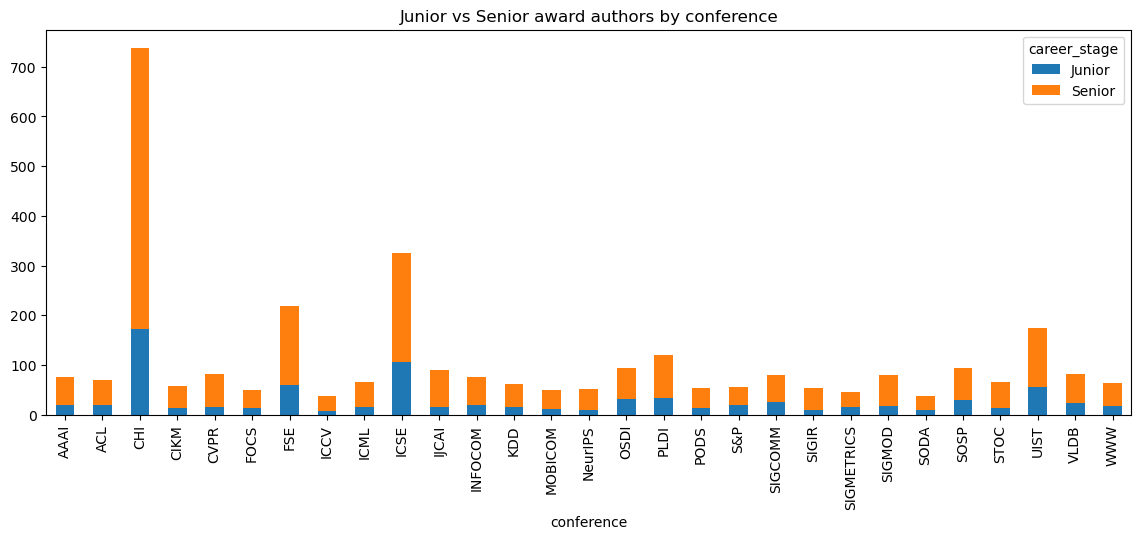

In [10]:
pd.crosstab(award_authors_full['conference'], award_authors_full['career_stage']).plot(
    kind='bar', stacked=True, figsize=(14,5), title='Junior vs Senior award authors by conference'
)


## Data Provenance Log Update


In [11]:
log_path = DATA_DIR / '00_data_sources_log.md'

new_entries = [
    "",
    "## Notebook 02 — Author profiles & career stage",
    f"- Author-paper pairs built from {len(matched)} matched award papers "
    f"(excluded {len(unmatched)} unmatched from notebook 01).",
    f"- Total author-paper pairs: {len(award_authors_long)}; unique authors: {award_authors_long['author_id'].nunique()}.",
    f"- Author entries skipped due to missing OpenAlex author id: {skipped_no_author_id}.",
    f"- OpenAlex /authors profiles fetched: {len(author_profiles)} ({len(failed_batches)} failed batches).",
    f"- Precise first-pub-year fallback lookups (/works endpoint): {len(needs_check)} authors.",
    f"- Authors still missing first_pub_year after fallback: {still_missing}.",
    f"- Career stage counts: {award_authors_full['career_stage'].value_counts(dropna=False).to_dict()}.",
    "- Definition: career_age_at_award = award_year - first_pub_year (absolute first pub, any field).",
    "- Junior: career_age <= 5. Senior: career_age >= 6.",
    "- LIMITATION: first_pub_year not restricted to CS-relevant works; may inflate career age for "
    "authors with prior publications in unrelated fields.",
    "",
    "### Output files (conf_data/)",
    "- 02_award_authors_long.csv — raw author-paper pairs",
    "- 02_author_profiles_raw.csv — OpenAlex author summary stats (pre-fallback)",
    "- 02_author_profiles.csv — with corrected first_pub_year",
    "- 02_award_authors_with_career_stage.csv — final analysis-ready table (Junior/Senior labeled)",
]

mode = 'a' if log_path.exists() else 'w'
with open(log_path, mode) as f:
    f.write("\n".join(new_entries))

print("Log updated.")


Log updated.
